In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


 1. **Preprocessing**

In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(mapping)

multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

features = [c for c in df.columns if c != 'Churn']
X = df[features]
y = df['Churn']

# Random Forest does NOT require scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5634, 30) | Test: (1409, 30)


2. **Baseline Model**

In [3]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

y_pred_base  = rf_baseline.predict(X_test)
y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

print('Baseline RF results:')
print(classification_report(y_test, y_pred_base, target_names=['Retained','Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}')

Baseline RF results:
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.86      1035
     Churned       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.8283


3. **Hyperparameter Tuning (GridSearchCV)**

In [5]:
# Note: increase param_grid for deeper search — this is a fast version
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest params : {grid_search.best_params_}')
print(f'Best CV AUC : {grid_search.best_score_:.4f}')
rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC : 0.8452


4. **Evaluate Best Model**

In [6]:
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print('='*45)
print('        RANDOM FOREST RESULTS')
print('='*45)
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

        RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    Retained       0.89      0.77      0.83      1035
     Churned       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

AUC-ROC: 0.8412


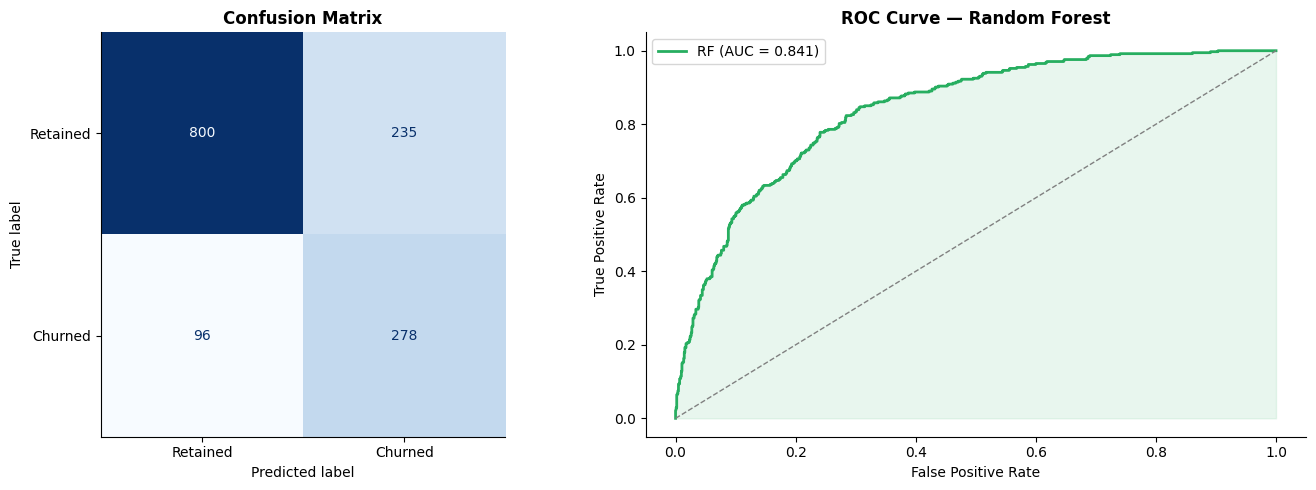

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Retained','Churned']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#27ae60', lw=2, label=f'RF (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#27ae60')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

5. **Feature Importance**

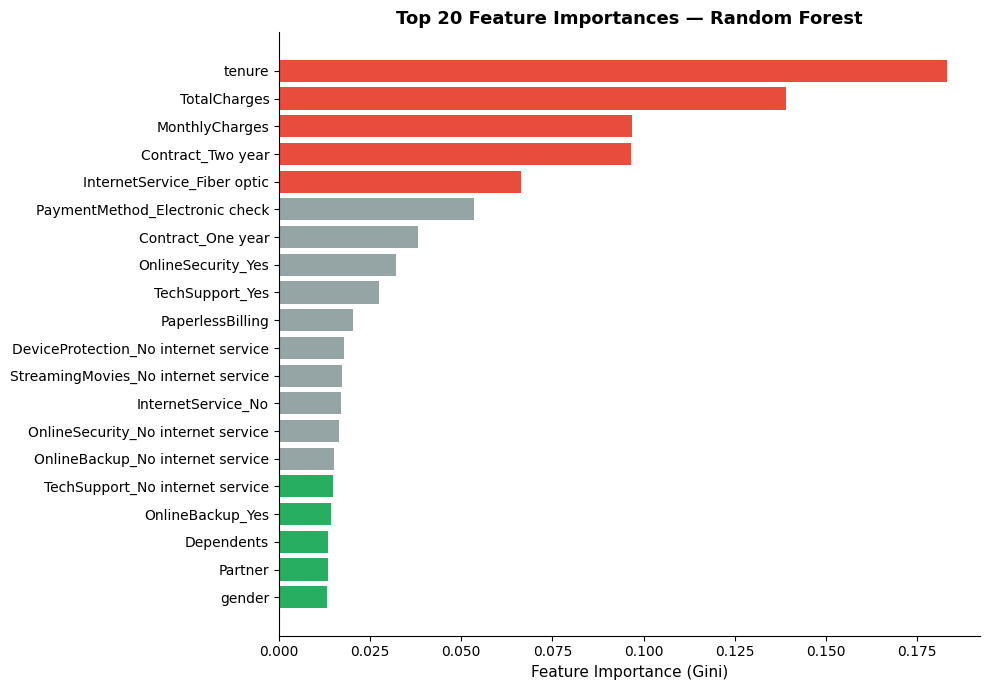


Top 10 features:
                       feature  importance
                        tenure    0.183125
                  TotalCharges    0.139106
                MonthlyCharges    0.096966
             Contract_Two year    0.096678
   InternetService_Fiber optic    0.066511
PaymentMethod_Electronic check    0.053493
             Contract_One year    0.038242
            OnlineSecurity_Yes    0.032226
               TechSupport_Yes    0.027466
              PaperlessBilling    0.020245


In [8]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
top20 = importance_df.head(20)
colors = ['#e74c3c' if i < 5 else '#27ae60' if i > 14 else '#95a5a6'
          for i in range(len(top20))]
plt.barh(top20['feature'], top20['importance'], color=colors)
plt.xlabel('Feature Importance (Gini)', fontsize=11)
plt.title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance_df.head(10).to_string(index=False))

6. **Score All Customers**

In [10]:
df_orig = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_orig['churn_probability_rf'] = rf_model.predict_proba(X)[:, 1]
df_orig['risk_segment'] = pd.cut(
    df_orig['churn_probability_rf'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

at_risk = df_orig.sort_values('churn_probability_rf', ascending=False)
print('Top 15 at-risk customers:')
print(at_risk[['customerID','tenure','MonthlyCharges','Contract',
               'churn_probability_rf','risk_segment']].head(15).to_string(index=False))

print('\nRisk segment breakdown:')
print(df_orig['risk_segment'].value_counts())

at_risk[['customerID','churn_probability_rf','risk_segment']].to_csv(
    'rf_churn_predictions.csv', index=False)
print('\nSaved: rf_churn_predictions.csv')

Top 15 at-risk customers:
customerID  tenure  MonthlyCharges       Contract  churn_probability_rf risk_segment
9497-QCMMS       1           93.55 Month-to-month              0.950614         High
9300-AGZNL       1           94.00 Month-to-month              0.950614         High
3068-OMWZA       1           88.80 Month-to-month              0.945733         High
1069-XAIEM       1           85.05 Month-to-month              0.944560         High
8149-RSOUN       1           93.85 Month-to-month              0.942724         High
4910-GMJOT       1           94.60 Month-to-month              0.941768         High
4826-XTSOH       1           86.05 Month-to-month              0.941463         High
5178-LMXOP       1           95.10 Month-to-month              0.941316         High
9248-OJYKK       1           76.45 Month-to-month              0.940920         High
6894-LFHLY       1           75.75 Month-to-month              0.940866         High
0295-PPHDO       1           95.45 Mont